In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\emgha\Downloads\UScomments.csv", on_bad_lines="skip")

C:\Users\emgha\AppData\Local\Temp\ipykernel_10908\674543399.py:3: DtypeWarning: Columns (0: likes, 1: replies) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\emgha\Downloads\UScomments.csv", on_bad_lines="skip")


In [3]:
df

,video_id,comment_text,likes,replies
0,XpVt6Z1Gjjo,Logan Paul it's yo big day ‼️‼️‼️,4,0
1,XpVt6Z1Gjjo,I've been following you from the start of your...,3,0
2,XpVt6Z1Gjjo,Say hi to Kong and maverick for me,3,0
3,XpVt6Z1Gjjo,MY FAN . attendance,3,0
4,XpVt6Z1Gjjo,trending 😉,3,0
...,...,...,...,...
691395,EoejGgUNmVU,Лучшая,1,0
691396,EoejGgUNmVU,qu'est ce que j'aimerais que tu viennes à Roan...,0,0
691397,EoejGgUNmVU,Ven a mexico! 😍 te amo LP,0,0
691398,EoejGgUNmVU,Islığı yeter...,0,0


In [4]:
!pip install nltk


In [5]:
import nltk

In [6]:
nltk.download("vader_lexicon")
from nltk.sentiment.vader import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\emgha\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [7]:
def analyze_comment_sentiment(comment):
    compound = sia.polarity_scores(comment)['compound']
    if compound > 0.05:
        label = 'positive :)'
    elif compound < 0.05:
        label = 'negative :('
    else:
        label = 'neutral :|'
    return{
        "label" : label,
        "score" : compound
    }

In [8]:
!pip install emoji

In [9]:
import emoji
emoji_list = []

for comment in df["comment_text"].dropna():
    for char in comment:
        if char in emoji.EMOJI_DATA:
            emoji_list.append(char)
        

In [10]:
emoji_list[0:10]

['‼', '‼', '‼', '😉', '😭', '👍', '🏻', '❤', '😍', '💋']

In [11]:
label_score = []
for comment in df["comment_text"].dropna():
    label_score.append(analyze_comment_sentiment(comment))
    

In [12]:
label_score[0:10]

[{'label': 'negative :(', 'score': 0.0},
 {'label': 'negative :(', 'score': 0.0},
 {'label': 'negative :(', 'score': 0.0},
 {'label': 'positive :)', 'score': 0.4648},
 {'label': 'negative :(', 'score': 0.0},
 {'label': 'negative :(', 'score': 0.0},
 {'label': 'negative :(', 'score': 0.0},
 {'label': 'negative :(', 'score': 0.0},
 {'label': 'positive :)', 'score': 0.5719},
 {'label': 'negative :(', 'score': -0.7717}]

In [13]:
from collections import Counter
emoji_count_list = Counter(emoji_list).most_common(10)
emojis = [emoji for emoji, count in emoji_count_list]
counts = [count for emoji, count in emoji_count_list]


In [14]:
!pip install plotly


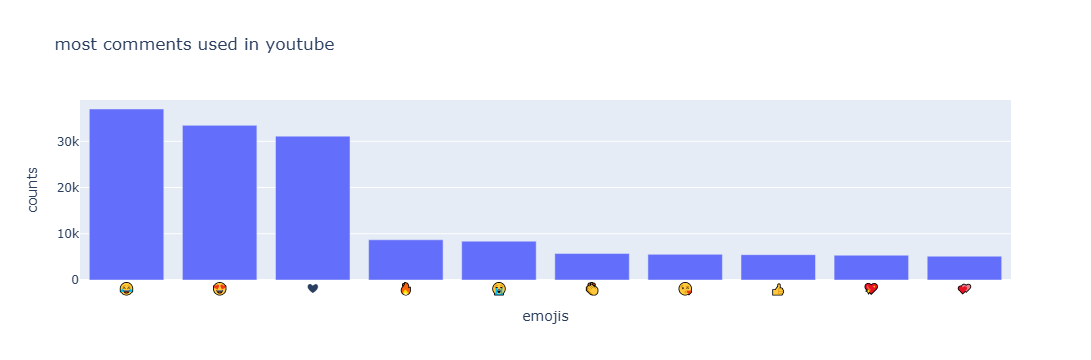

In [15]:
import plotly.express as px
fig = px.bar(
        x = emojis,
        y = counts,
        title = "most comments used in youtube",
        labels ={
        "x": "emojis",
        "y": "counts"
        }
    
    )
fig

In [16]:
import plotly.io as pio
pio.renderers.default = "iframe"

fig.show()

In [17]:
import os

In [18]:
files = os.listdir(r"C:\Users\emgha\Downloads\additional_data")

In [19]:
csv_file = [file for file in files if ".csv" in file]
    

In [20]:
path = r"C:\Users\emgha\Downloads\additional_data"
full_df = pd.DataFrame()

for file in csv_file:
    current_df = pd.read_csv(path + '/' + file, encoding= 'iso-8859-1', on_bad_lines = 'skip')
    full_df = pd.concat([current_df, full_df], ignore_index = True)

ParserError: Error tokenizing data. C error: out of memory

In [ ]:
full_df.columns

In [ ]:
full_df[full_df.duplicated()].shape

In [ ]:
full_df = full_df.drop_duplicates()

In [ ]:
full_df.shape

In [ ]:
full_df[0:1000].to_json(r"")


In [ ]:
!pip install sqlalchemy

In [ ]:
from sqlalchemy import create_engine

In [ ]:
engine = create_engine(r"sqlite:///")

In [ ]:
full_df.dtypes

In [ ]:
full_df["trending_date"]

In [ ]:
full_df["trending_date"] = pd.to_datetime(
    full_df["trending_date"],
    format="%y.%d.%m"
)

In [ ]:
import json
path = r"C:\Users\emgha\Downloads\additional_data\us_category_id.json"
with open (path, 'r' , encoding= "utf_8") as f:
    data = json.load(f)

In [ ]:
data

In [ ]:
data['items'][0]['snippet']['title']

In [ ]:
data['items'][0]['id']

In [ ]:
cat_dict = {}
for item in data["items"]:
   cat_dict[int(item['id'])] = item['snippet']['title']

In [ ]:
cat_dict

In [ ]:
full_df

In [ ]:
full_df["category_name"] = full_df["category_id"].map(cat_dict)

In [ ]:
full_df

In [ ]:
full_df.groupby(["trending_date", "category_name"])["views"].sum()

In [ ]:
pivot_df = full_df.groupby(["trending_date", "category_name"])["views"].sum().unstack(fill_value = 0)
pivot_df

In [ ]:
area_chart = px.area(
    data_frame = pivot_df , 
    x = pivot_df.index ,
    y = pivot_df.columns ,
    title = "Trending Momentum over time by category"
)

In [ ]:
area_chart

In [ ]:
top_categories = full_df.groupby(["category_name"])["views"].sum().nlargest(6).index
top_categories

In [ ]:
filter_df = pivot_df[top_categories]
filter_df

In [ ]:
area_chart = px.area(
    data_frame = filter_df , 
    x = filter_df.index ,
    y = filter_df.columns ,
    title = "Trending Momentum over time by top 6 categories"
)
area_chart

In [ ]:
full_df.columns

In [ ]:
full_df['engagement_rate'] = (full_df['likes'] + full_df['comment_count']) / full_df['views']

In [ ]:
bubble_sample = full_df.sample(50000)

In [ ]:
bubble = px.scatter(bubble_sample,
          x = 'views',
          y = 'engagement_rate',
          size = 'comment_count',
          color = 'category_name',
          hover_name = 'title',
          title = 'engagement Bubble Map : Views vs Engagement rate',
          size_max = 60)

In [ ]:
bubble

In [ ]:
bubble.update_xaxes(type = 'log')

In [ ]:
category_metric= full_df.groupby('category_name').agg( 
                                    total_views = ('views', 'sum'),
                                    avg_engagement_efficienty =('engagement_rate','mean'),
                                    video_count =('video_id','count')).reset_index()


In [ ]:
category_metric.columns

In [ ]:
category_metric.isna().sum()

In [ ]:
treemap = px.treemap(
          category_metric ,
          path = ['category_name'],
          values = 'total_views',
          color = 'avg_engagement_efficienty',
          color_continuous_scale = 'RdYlGn',
          title = 'Category Attention Share with Engagement Efficiency overlay',  
          hover_data ={
              'total_views': ':,.0f',
              'avg_engagement_efficienty':':.3f',
              'video_count': True
          }
          )

In [ ]:
treemap

In [ ]:
full_df['engagement_rate'].describe()

In [ ]:
category_engagement_stats = full_df.groupby('category_name')['engagement_rate'].describe()
category_engagement_stats.sort_values('mean', ascending= False)

In [ ]:
full_df.columns

In [ ]:
box = px.box(full_df , 
       x = 'category_name',
       y = 'engagement_rate',
       color = 'category_name',
       title = 'Audience Engagement by Category')

box